# Clase 15: Deep Learning 1

- Rama del machine learning basada en redes neuronales con múltiples capas.

- Aprende automáticamente representaciones cada vez más complejas de los datos.

- Cada capa transforma la información recibida y la transmite a la siguiente.

- El entrenamiento consiste en ajustar millones de parámetros mediante optimización y descenso por gradiente.

- Puede modelar relaciones altamente no lineales.

- Las redes neuronales son una de las principales técnicas utilizadas en inteligencia artificial para aprender patrones y realizar tareas como clasificación, predicción, reconocimiento de imágenes/visión artificial (computer vision), lenguaje natural (LLMs) y reconocimiento de patrones en todo tipo de datos.

## Tipos de redes neuronales

- **Redes convolucionales (CNN):** se usan para clasificar imágenes, espectros. Se basan en suavizar los datos para reconocer patrones a gran escala espacial.

- **Redes recurrentes (RNN):** diseñadas para datos secuenciales; incorporan memoria de estados anteriores y se utilizan en series temporales, lenguaje natural y procesamiento de señales.

- **LSTM y GRU:** variantes de las RNN que mejoran la capacidad de recordar información a largo plazo y reducen problemas de entrenamiento.

- **Autoencoders:** aprenden una representación comprimida de los datos y se utilizan para reducción de dimensionalidad, eliminación de ruido y detección de anomalías.

- **Transformers:** basados en mecanismos de atención (*attention*); son actualmente la arquitectura dominante en procesamiento de lenguaje natural y también se utilizan en imágenes y series temporales.

- **GANs (Generative Adversarial Networks):** emplean dos redes que compiten entre sí para generar datos sintéticos realistas, como imágenes, audio o simulaciones.

---

## Neurona artificial

- Es la unidad básica de una red neuronal.

- Recibe varias entradas, las combina mediante pesos ajustables y produce una salida.

- Cada entrada tiene asociada una importancia o peso.

- La neurona calcula primero una suma ponderada de las entradas:

$$
z = \sum_{i=1}^{n} w_i x_i + b
$$

donde:

- $x_i$ son las variables de entrada,
- $w_i$ son los pesos,
- $b$ es el sesgo (*bias*).


### Función de activación

El resultado anterior se transforma mediante una función no lineal:

$$
y = f(z)
$$

donde $f$ es la función de activación. Como la cantidad

$$
z=w\cdot x+b
$$

define un hiperplano en el espacio de variables, la función de activación permite transformar esa frontera lineal en bloques capaces de construir relaciones no lineales complejas cuando muchas neuronas se combinan en capas, generando *kernels* que parten el espacio de forma arbitrariamente selectiva.


### Ejemplos de funciones de activación

#### Sigmoide (logística)

$$
f(z)=\frac{1}{1+e^{-z}}
$$

- Produce valores entre 0 y 1.
- Puede interpretarse como una probabilidad.


#### ReLU

$$
f(z)=\max(0,z)
$$

- Muy utilizada en redes profundas.
- Introduce no linealidad con bajo costo computacional.


#### Tangente hiperbólica

$$
f(z)=\tanh(z)
$$

- Produce valores entre -1 y 1.

#### Softmax

Tipo especial de función de activación. Transforma las salidas de una red neuronal en probabilidades normalizadas cuya suma es igual a 1, permitiendo interpretar cada salida como la probabilidad de pertenecer a una clase determinada.


---

## Redes neuronales (neural networks)

- Modelos de machine learning compuestos por capas de neuronas artificiales interconectadas.

- Cada neurona realiza una combinación lineal de las entradas seguida de una transformación no lineal.

- La información fluye desde una capa de entrada, a través de una o más capas ocultas, hasta una capa de salida.

- Durante el entrenamiento, los pesos de las conexiones se ajustan para minimizar una función de pérdida.

- Son aproximadores universales capaces de modelar relaciones complejas y altamente no lineales entre variables.

- [NNs en sklearn](https://scikit-learn.org/stable/modules/neural_networks_supervised.html).




## Clasificación de Objetos a partir de Flujos IR

Vamos a construir una red neuronal muy sencilla para generar un modelo de Deep Learning con los datos del survey RMS - [Red MSX Sources](https://academic.oup.com/mnras/article/527/3/8054/7459353). Este survey analizó y clasificó más de 2000 objetos brillantes en IR usando datos de muchas longitudes de onda de los telescopios MSX, 2MASS, y Spitzer.

In [ ]:
!wget https://raw.githubusercontent.com/saint-germain/YSO-RF-classifier/refs/heads/master/rms_high_qf.csv

Vamos a dejar únicamente clases sobre las que haya certeza (sin '?' en Source Type) y que no sean tampoco de tipo 'Rejected'.

In [ ]:
from astropy.table import Table
import numpy as np

data_table = Table.read('rms_high_qf.csv', format='csv')

print(f"Original table size: {len(data_table)} rows")

# Remove rows where 'Source Type' contains '?'
initial_rows = len(data_table)
mask = ['?' not in s for s in data_table['Source Type']]
data_table = data_table[mask]

mask = ['Rejected' not in s for s in data_table['Source Type']]
data_table = data_table[mask]


print(f"Table size after removing 'Source Type' with '?' and 'Rejected': {len(data_table)} rows (removed {initial_rows - len(data_table)} rows)")

display(data_table[:5])


In [ ]:
unique_source_types, counts = np.unique(data_table['Source Type'], return_counts=True)

for value, count in zip(unique_source_types, counts):
    print(f"{value}: {count}")

También vamos a quitar categorías con menos de 50 miembros.

In [ ]:
source_type_counts = dict(zip(unique_source_types, counts))

low_count_source_types = [s_type.item() for s_type, count in source_type_counts.items() if count < 50]

print(f"Source Types to be removed due to less than 50 members: {low_count_source_types}")

initial_rows_after_cleaning = len(data_table)
# Filter the data_table to remove rows with low-count 'Source Type' labels
data_table = data_table[~np.isin(data_table['Source Type'], low_count_source_types)]

print(f"Table size after removing low-count 'Source Types': {len(data_table)} rows (removed {initial_rows_after_cleaning - len(data_table)} rows)")


Pasamos de labels descriptivos a numéricos.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(data_table['Source Type'])
data_table['encoded_source_type'] = encoded_labels
print("\nMapping of original 'Source Type' to encoded numerical labels:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")
y = encoded_labels

Ahora estandarizamos los datos y seleccionamos los features (esos flujos son las únicas columnas completas).

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Identify numerical features to scale
feature_columns = ['Flux 8 (Jy)', 'Flux 12 (Jy)', 'Flux 14 (Jy)', 'Flux 21 (Jy)']

# Convert selected features to a NumPy array ensuring it's a homogeneous float type
# Extract each column as a float64 numpy array and then stack them
X = np.column_stack([np.asarray(data_table[col], dtype=np.float64) for col in feature_columns])

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

print(f"Shape of original features X: {X.shape}")
print(f"Shape of scaled features X_scaled: {X_scaled.shape}")

# Display the first 5 rows of scaled features
print("\nFirst 5 rows of scaled features:")
print(X_scaled[:5])

Ahora hacemos la partición train/validate/test.

In [ ]:
# Using 70% for training, 15% for validation, and 15% for testing

# First, split into training and (validation + test) sets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.30, random_state=42, stratify=y)

# Then, split the (validation + test) set into validation and test sets
# (0.15 / 0.30) = 0.5, so we split the temp set in half
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Vamos a crear una red neuronal mínima, donde pasamos todos los datos (capa input) a 64 neuronas y la salida de esas 64 neuronas la pasamos a la capa de predicción o output. Se puede probar a añadir una capa intermedia:

````
    layers.Dense(32, activation='relu'),                                   # Second hidden layer
`````

Al hacer esto el modelo debería aprender en menos "épocas".

In [ ]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),  # Input layer with number of features
    keras.layers.Dense(64, activation='relu'),      # Hidden layer with 64 neurons and ReLU activation
    keras.layers.Dense(len(label_encoder.classes_), activation='softmax') # Output layer with 'num_classes' neurons and softmax activation
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

A continuación entrenaremos el modelo entregándole "batches" de datos en distintas interaciones ("épocas"). El número total de "batches" es igual al total de datos sobre el `batch_size` (38 en este caso).

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=150,          # Number of training epochs
    batch_size=32,      # Number of samples per gradient update
    validation_split=0.2, # Use a portion of the training data for validation
    verbose=1           # Show progress during training
)

print("\nModel training complete!")

Ahora evaluaremos el *accuracy* y el valor de la función de pérdida para las distintas épocas. La idea es que monitoreamos estos valores para los datos de entrenamiento y de validación, buscando la "epoch" donde se minimiza la pérdida (*loss*) de validación, evitando sobreajustar (*overfitting*). Esto se encuentra cuando el loss deja de bajar y empieza a volver a subir.

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Revisemos la matriz de confusión sobre los datos de *test*, que el modelo no ha visto.

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the model on the test set
y_pred_probabilities = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Get the class names from the label encoder
class_names = label_encoder.classes_

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

El reporte de clasificación nos entrega las probabilidades de predicción del modelo. Teniendo en cuenta que hay 7 clases, el lanzamiento de un dado tendría una probabilidad de asignación de clases del orden de 1/7 --> 14% aproximadamente. ¿Es el modelo mejor o peor que usar pura suerte?

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred_classes,
    target_names=label_encoder.classes_,
    zero_division=0 # Handle cases where a class has no samples or no predictions
)

print("Classification Report:")
print(report)

**Ejercicio:** Añada una capa intermedia adicional como se indicó más arriba. ¿Esto logra mejorar las métricas?


**Ejercicio:** Use datos de Herschel de 70 micrones como se muestra a continuación para generar un nuevo modelo.

In [ ]:
!wget https://raw.githubusercontent.com/saint-germain/YSO-RF-classifier/refs/heads/master/Flux_70.csv

In [ ]:
flux_70_table = Table.read('Flux_70.csv', format='csv')

Por medio de un inner join se dejan únicamente las fuentes que tienen todos los datos de flujo completos (8,12,14,21,70 micron). Pruebe a correr un modelo con esos datos.

In [ ]:
from astropy.table import join
merged_table = join(data_table, flux_70_table, keys_left='MSX Name', keys_right='Name', join_type='inner')

Por medio de un left join se añaden los datos de 70 micrones al resto de la tabla, dejando valores faltantes cuando así corresponde. Es posible correr un modelo con datos faltantes como veremos a continuación.

In [ ]:
merged_table = join(data_table, flux_70_table, keys_left='MSX Name', keys_right='Name', join_type='left')

Con la función `SimpleImputer` se puede rellenar los datos faltantes (en este caso con los promedios de cada columna) para correr un modelo con muchas más fuentes. En el ejemplo a continuación únicamente se añade la columna de `Flux_70`, pero se sugiere usar las demás columnas (magnitud en bandas H,J,K, otros flujos). No olvide estandarizar los datos antes de pasarlos al modelo.

In [ ]:
from sklearn.impute import SimpleImputer
feature_columns = ['Flux 8 (Jy)', 'Flux 12 (Jy)', 'Flux 14 (Jy)', 'Flux 21 (Jy)','Flux_70']

X_df = merged_table[feature_columns].to_pandas()

# Ensure all columns are numeric, coercing errors to NaN
for col in feature_columns:
    X_df[col] = pd.to_numeric(X_df[col], errors='coerce')

# Impute missing values (NaNs) with the mean of each column
# also available: median, constant, most_frequent
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_df)

**Ejercicio**: Pruebe a hacer *feature engineering*, pasándole al modelo índices de color o flux ratios en vez de los datos crudos para ver si mejora el modelo. Haga análisis de feature importance para encontrar cuál de estos features es el que más ayuda a la predicción.



## Convolutional Neural Networks (CNN)

- Tipo de red neuronal diseñada para procesar imágenes y datos con estructura espacial.

- Utiliza filtros (*kernels*) que recorren la imagen buscando patrones locales.

- Los mismos filtros se aplican en toda la imagen, reduciendo el número de parámetros necesarios.

- Las capas iniciales suelen detectar características simples:
  - bordes,
  - líneas,
  - texturas.

- Las capas profundas combinan estas características para reconocer estructuras más complejas.

### Componentes principales

- Capas convolucionales (*convolutional layers*)
- Capas de agrupamiento (*pooling*)
- Funciones de activación
- Capas densas (*fully connected*)
- La convolución detecta características; el pooling las resume y reduce la resolución espacial conservando la información más relevante.


## Convolución

- Operación matemática utilizada para detectar patrones locales en una imagen.

- Consiste en desplazar un pequeño filtro (*kernel*) sobre la imagen y calcular una suma ponderada de los píxeles vecinos.

- Cada filtro aprende a responder a características específicas como bordes, líneas, texturas o estructuras más complejas.

- El resultado es un **mapa de características** (*feature map*) que indica dónde aparece cada patrón en la imagen.

- Si $I$ es la imagen y $K$ el filtro:

$$
S(i,j)
=
\sum_m \sum_n
I(i+m,j+n)\,K(m,n)
$$

donde $S$ es el mapa de características producido por la convolución.


## Pooling

- Operación que reduce el tamaño de los mapas de características.

- Resume la información de pequeñas regiones vecinas.

- Disminuye el número de parámetros y el costo computacional.

- Hace que la red sea menos sensible a pequeños desplazamientos o ruido.

### Max Pooling

La forma más común consiste en conservar únicamente el valor máximo dentro de una ventana.

Por ejemplo:

$$
\begin{bmatrix}
1 & 3\\
2 & 5
\end{bmatrix}
\quad\rightarrow\quad
5
$$

### Average Pooling

Utiliza el promedio de los valores dentro de la ventana.

## Capas densas (*Fully Connected Layers*)

- Son capas en las que cada neurona está conectada con todas las salidas de la capa anterior.

- Reciben las características extraídas por las capas previas y las combinan para realizar la predicción final.

- Esta predicción puede ser categórica (esta clase) o continua (regresión, próxima clase)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Define the Input Data and Kernel
# A 6x6 matrix representing an image feature (e.g., a vertical edge)
input_matrix = np.array([
    [10, 10, 10,  0,  0,  0],
    [10, 10, 10,  0,  0,  0],
    [10, 10, 10,  0,  0,  0],
    [ 0,  10,  10, 10, 0, 0],
    [ 0,  10,  10, 10, 0, 0],
    [ 0,  10,  10, 10, 0, 0]
])

# A 3x3 Sobel-like kernel to detect vertical edges
kernel = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1]
])

# 2. Perform 2D Convolution (Valid padding, Stride = 1)
conv_shape = input_matrix.shape[0] - kernel.shape[0] + 1
conv_output = np.zeros((conv_shape, conv_shape))

for r in range(conv_shape):
    for c in range(conv_shape):
        # Extract the current receptive field (window)
        window = input_matrix[r:r+3, c:c+3]
        # Element-wise multiplication and summation
        conv_output[r, c] = np.sum(window * kernel)

# 3. Perform Max Pooling (2x2 window, Stride = 2)
pool_size = 2
pool_output = np.zeros((conv_shape // pool_size, conv_shape // pool_size))

for r in range(0, conv_shape, pool_size):
    for c in range(0, conv_shape, pool_size):
        window = conv_output[r:r+pool_size, c:c+pool_size]
        pool_output[r//pool_size, c//pool_size] = np.max(window)

# 4. Plotting the Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cmap = "YlGnBu"

# Helper function to annotate matrix values on the plot
def annotate_matrix(ax, matrix):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, int(matrix[i, j]), ha="center", va="center",
                    color="white" if matrix[i, j] > np.max(matrix)/2 else "black",
                    fontweight='bold')

# Plot 1: Input Matrix with an example 3x3 Convolution window highlighted
axes[0].imshow(input_matrix, cmap=cmap)
axes[0].set_title("1. Input Matrix (6x6)\n(Red box = 3x3 Convolution Window)", fontsize=12)
# Draw a red rectangle showing where the kernel sits at step (0,0)
rect_conv = patches.Rectangle((-0.5, -0.5), 3, 3, linewidth=3, edgecolor='red', facecolor='none')
axes[0].add_patch(rect_conv)
annotate_matrix(axes[0], input_matrix)

# Plot 2: Convolution Output with an example 2x2 Pooling window highlighted
axes[1].imshow(conv_output, cmap=cmap)
axes[1].set_title("2. After 2D Convolution (4x4)\n(Magenta box = 2x2 Pool Window)", fontsize=12)
# Draw a magenta rectangle showing the first pooling step
rect_pool = patches.Rectangle((-0.5, -0.5), 2, 2, linewidth=3, edgecolor='magenta', facecolor='none')
axes[1].add_patch(rect_pool)
annotate_matrix(axes[1], conv_output)

# Plot 3: Max Pooling Output
axes[2].imshow(pool_output, cmap=cmap)
axes[2].set_title("3. After Max Pooling (2x2)\n(Downsampled Feature Map)", fontsize=12)
annotate_matrix(axes[2], pool_output)

# Formatting adjustments
for ax in axes:
    ax.set_xticks(np.arange(-0.5, ax.get_xlim()[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ax.get_ylim()[1], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

plt.tight_layout()
plt.show()

## Reconocimiento de números

- MNIST (*Modified National Institute of Standards and Technology*) es uno de los conjuntos de datos más utilizados para aprender redes neuronales y clasificación de imágenes.

- Contiene imágenes de dígitos escritos a mano correspondientes a las clases:

$$
0,1,2,\ldots,9
$$

- Cada imagen está etiquetada con el número que representa.

## TensorFlow

- **TensorFlow** es una biblioteca de código abierto desarrollada por Google para deep learning.

- Proporciona herramientas para definir, entrenar y desplegar modelos de aprendizaje automático de manera eficiente.

- Está optimizada para ejecutar cálculos numéricos en CPU, GPU y otros aceleradores de hardware.

## Keras

- **Keras** es una interfaz de alto nivel integrada en TensorFlow.

- Permite construir redes neuronales mediante una sintaxis sencilla y modular.

- Oculta gran parte de la complejidad matemática e implementación de TensorFlow.


### Estructura de la CNN

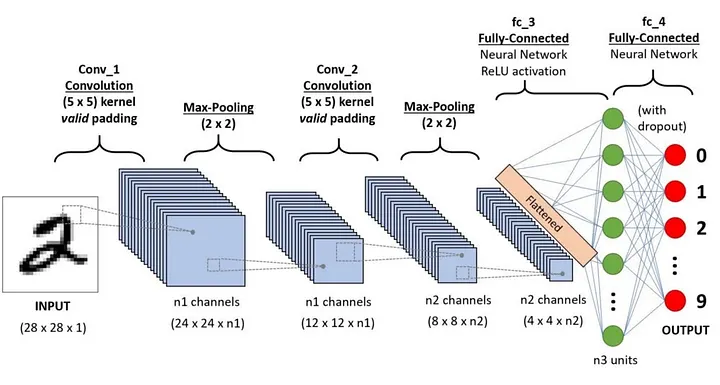

Imagen original de este [tutorial](https://medium.com/data-science/a-simple-guide-to-convolutional-neural-networks-751789e7bd88).

In [ ]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load the digits dataset
digits = load_digits()
X, y = digits.data, digits.target

print(f"Original data shape: {X.shape}")
print(f"Original target shape: {y.shape}")

The dataset contains 1797 images of handwritten digits (0-9). Each image is an 8x8 pixel grayscale image, flattened into a 64-element array. We need to reshape these into a 3D format (height, width, channels) for a CNN, and also normalize the pixel values.

In [ ]:
# Reshape the data for CNN input (8x8 images, 1 channel for grayscale)
X_reshaped = X.reshape(-1, 8, 8, 1)

# Normalize the image data to [0, 1] range
X_normalized = X_reshaped / 16.0 # Digits pixel values are 0-16

# Convert target labels to one-hot encoding
y_one_hot = to_categorical(y)

print(f"Reshaped and normalized data shape: {X_normalized.shape}")
print(f"One-hot encoded target shape: {y_one_hot.shape}")

Now, let's split the data into training and testing sets to evaluate our model's performance on unseen data.

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_one_hot, test_size=0.2, random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

Let's visualize a few sample images from the dataset to understand the data better.

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(8, 8), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Now, let's define our Convolutional Neural Network (CNN) model using Keras. We will use a sequential model with a few convolutional layers, max-pooling layers, and then flatten the output before passing it to dense layers for classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # 10 classes for digits 0-9
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

## Arquitectura de la red

Esta red neuronal convolucional (CNN) recibe imágenes de

$$
8 \times 8
$$

pixeles en escala de grises y produce una clasificación entre 10 clases posibles (los dígitos del 0 al 9).

---

### Capa convolucional 1

```python
Conv2D(32, (3,3), activation='relu')
```

- Aplica 32 filtros de tamaño:

$$
3 \times 3
$$

- Cada filtro busca patrones locales en la imagen.
- La función ReLU introduce no linealidad generando fronteras de decisión.

---

### Pooling

```python
MaxPooling2D((2,2))
```

- Reduce la resolución espacial de los mapas de características.
- Conserva únicamente los valores máximos en regiones:

$$
2 \times 2
$$

- Reduce costo computacional y sensibilidad al ruido.

---

### Capa convolucional 2

```python
Conv2D(64, (3,3), activation='relu')
```

- Aplica 64 filtros nuevos.
- Aprende características más complejas a partir de los patrones encontrados por la primera capa.

---

### Flatten

```python
Flatten()
```

- Convierte los mapas bidimensionales de características en un único vector unidimensional.

- Prepara la información para las capas densas.

---

### Capa densa oculta

```python
Dense(64, activation='relu')
```

- Contiene 64 neuronas completamente conectadas.
- Combina todas las características extraídas por las capas convolucionales.

---

### Capa de salida

```python
Dense(10, activation='softmax')
```

- Contiene 10 neuronas.
- Cada neurona corresponde a un dígito:

$$
0,1,\ldots,9
$$

- La función Softmax convierte las salidas en probabilidades:

$$
\sum_i p_i = 1
$$

---

## Entrenamiento

```python
optimizer='adam'
```

- Utiliza Adam, una variante avanzada de Gradient Descent.

```python
loss='categorical_crossentropy'
```

- Minimiza el error entre las probabilidades predichas y las clases verdaderas.

```python
metrics=['accuracy']
```

- Evalúa el porcentaje de clasificaciones correctas.

---

## Flujo completo

```text
Imagen 8×8
      ↓
Conv2D (32 filtros)
      ↓
MaxPooling
      ↓
Conv2D (64 filtros)
      ↓
Flatten
      ↓
Dense (64)
      ↓
Dense (10)
      ↓
Probabilidades de los dígitos
```

### En resumen:

Las capas convolucionales extraen patrones visuales de la imagen, el pooling reduce la dimensionalidad, las capas densas combinan la información extraída y la capa Softmax produce la probabilidad de pertenecer a cada uno de los diez dígitos posibles.

### En la práctica:

- Debemos monitorear que la exactitud del modelo no genere overfitting a través de las "épocas" de entrenamiento.

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Visualicemos las predicciones del modelo.

In [ ]:
predictions = model.predict(X_test)

plt.figure(figsize=(10, 8))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    predicted_label = np.argmax(predictions[i])
    true_label = np.argmax(y_test[i])
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

Veamos la matriz de confusión para evaluar el modelo.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predicted labels (not one-hot encoded)
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Visualización de mapas de características

Visualizar los mapas de características (*feature maps*) producidos por una capa convolucional puede proporcionar información sobre los patrones que la red está aprendiendo en diferentes niveles de profundidad. Tomemos un ejemplo del conjunto de prueba y observemos sus activaciones después de la primera capa convolucional.

In [ ]:
from tensorflow.keras.models import Model

# Choose an example image from the test set
sample_image = X_test[0]
sample_true_label = np.argmax(y_test[0])

# Create a model that outputs activations from the first Conv2D layer
# You can change `model.layers[0]` to any Conv2D layer you want to inspect
feature_map_model = Model(inputs=model.inputs, outputs=model.layers[0].output)

# Get the feature maps for the sample image
feature_maps = feature_map_model.predict(np.expand_dims(sample_image, axis=0))

# Squeeze the batch dimension to make it easier to plot
feature_maps = np.squeeze(feature_maps, axis=0)

# Plot the original image in a separate figure
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.reshape(8, 8), cmap='gray')
plt.title(f"Original Image\nTrue Label: {sample_true_label}")
plt.axis('off')
plt.show()

# Create a new figure for visualizing each feature map
num_feature_maps = feature_maps.shape[2]
cols = 8 # Number of columns for displaying feature maps
rows = (num_feature_maps + cols - 1) // cols # Calculate rows needed

plt.figure(figsize=(15, rows * 2))
plt.suptitle(f"Feature Maps from First Conv2D Layer (Input: Digit {sample_true_label})")
for i in range(num_feature_maps):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(feature_maps[:, :, i], cmap='viridis') # Using viridis for better contrast
    plt.title(f"Map {i+1}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Visualización de mapas de características después de Max Pooling

Ahora visualizaremos los mapas de características después de la primera capa `MaxPooling2D`. Notará que estos mapas tienen dimensiones espaciales más pequeñas debido al proceso de reducción de resolución (*downsampling*), pero conservan las características más importantes identificadas previamente por la capa convolucional.

In [ ]:
from tensorflow.keras.models import Model

# Choose the same example image from the test set
sample_image = X_test[0]
sample_true_label = np.argmax(y_test[0])

# Create a model that outputs activations from the first MaxPooling2D layer
# The first MaxPooling2D layer is `model.layers[1]`
pooling_feature_map_model = Model(inputs=model.inputs, outputs=model.layers[1].output)

# Get the feature maps for the sample image after pooling
pooling_feature_maps = pooling_feature_map_model.predict(np.expand_dims(sample_image, axis=0))

# Squeeze the batch dimension
pooling_feature_maps = np.squeeze(pooling_feature_maps, axis=0)

# Plot the original image in a separate figure
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.reshape(8, 8), cmap='gray')
plt.title(f"Original Image\nTrue Label: {sample_true_label}")
plt.axis('off')
plt.show()

# Create a new figure for visualizing each pooled feature map
num_pooled_feature_maps = pooling_feature_maps.shape[2]
cols = 8 # Number of columns for displaying feature maps
rows = (num_pooled_feature_maps + cols - 1) // cols # Calculate rows needed

plt.figure(figsize=(15, rows * 2))
plt.suptitle(f"Feature Maps from First MaxPooling2D Layer (Input: Digit {sample_true_label})")
for i in range(num_pooled_feature_maps):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(pooling_feature_maps[:, :, i], cmap='plasma') # Using plasma for contrast
    plt.title(f"Pooled Map {i+1}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualizing Weights of the First Conv2D Layer

To understand what features the first convolutional layer is looking for, we can visualize its weights (the filters). Each filter will highlight different patterns, such as edges or corners, in the input image.

In [ ]:
# Get the weights from the first convolutional layer (model.layers[0])
weights = model.layers[0].get_weights()[0] # [0] for kernel weights, [1] for biases

# Normalize weights for visualization (optional, but can improve contrast)
# Scale weights to [0, 1] range for better visual representation
min_w, max_w = weights.min(), weights.max()
weights = (weights - min_w) / (max_w - min_w)

num_filters = weights.shape[3] # Number of filters
kernel_size = weights.shape[0] # e.g., 3x3

cols = 8 # Number of columns for displaying filters
rows = (num_filters + cols - 1) // cols # Calculate rows needed

plt.figure(figsize=(15, rows * 2))
plt.suptitle("Filters (Weights) of the First Conv2D Layer")
for i in range(num_filters):
    # Get the i-th filter
    filter_i = weights[:, :, 0, i] # For single-channel input, the third dim is 0

    plt.subplot(rows, cols, i + 1)
    plt.imshow(filter_i, cmap='gray') # Display filter weights as grayscale images
    plt.title(f"Filter {i+1}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## Ejercicio: Encontrar objetos transneptunianos (TNOs)

El proyecto busca detectar **objetos transneptunianos (TNOs)**, cuerpos helados que orbitan más allá de Neptuno (como Plutón o Eris). Debido a sus enormes distancias, estos objetos se desplazan muy lentamente sobre el fondo del cielo y aparecen extremadamente débiles en las imágenes obtenidas por los telescopios.

Los datos que vamos a usar provienen de un sondeo de **objetos cercanos a la Tierra (NEOs, *Near-Earth Objects*)** realizado por **Lori Allen** y sus colaboradores utilizando la cámara **DECam** instalada en el telescopio **Blanco de 4 metros** en el observatorio **CTIO** (*Cerro Tololo Inter-American Observatory*). [Más información.](https://www.astroml.org/astroML-notebooks/chapter9/astroml_chapter9_Deep_Learning_Classifying_Astronomical_Images.html)

### Apilamiento

Como estos objetos son demasiado débiles para detectarse en una única exposición, los astrónomos adquieren una serie de imágenes distribuidas a lo largo de cinco noches.

- Se calculan posibles trayectorias orbitales que podría seguir un TNO.
- Para cada trayectoria, las imágenes se desplazan (*shift*) de manera que un objeto moviéndose según esa trayectoria quede alineado.
- Posteriormente las imágenes se suman o apilan (*coadd*).


Si la trayectoria asumida es correcta, el TNO aparecerá en la misma posición en todas las imágenes alineadas y su señal se sumará coherentemente, produciendo una fuente puntual brillante y claramente detectable.

Por el contrario, el ruido de fondo y las fluctuaciones aleatorias no están correlacionadas entre imágenes, por lo que tienden a promediarse y disminuir al realizar el apilamiento.

---

## Verdaderos positivos y falsos positivos

Para entrenar un algoritmo de inteligencia artificial capaz de distinguir objetos reales de ruido de fondo, los investigadores construyeron dos conjuntos de datos utilizando archivos `.npz` (arreglos de NumPy comprimidos).

### `stamps_sources.npz` (verdaderos positivos)

- Contiene pequeños recortes de imagen (*stamps*) que incluyen TNOs simulados.
- Como la posición de cada objeto simulado es conocida, estas muestras representan ejemplos de que hay un TNO real.

- Se utilizan como ejemplos positivos durante el entrenamiento.

### `stamps_noise.npz` (falsos positivos)

- Contiene recortes generados al apilar imágenes siguiendo trayectorias aleatorias e incorrectas donde no existe ningún objeto.
- Estas imágenes contienen únicamente ruido de fondo, artefactos instrumentales o fluctuaciones estadísticas. Representan ejemplos de una no-detección de un TNO.

- Se utilizan como ejemplos negativos para entrenar el clasificador.

---

### Objetivo

Use las imágenes en la base de datos para entrenar un modelo de Deep Learning (idealmente una CNN) para clasificar detecciones/no-detecciones de TNOs.

In [ ]:
# Brute force direct downloads source and noise images to circumvent size limitations
# for google drive internal virus scan. Download may take some time.

import os
import requests

files = {'sources': (os.path.join('data', 'stamps_noise.npy'), '1UT2BCf-IDUEpvTmcU4bq6nDcY3Ayw5vJ'),
         'noise': (os.path.join('data', 'stamps_sources.npy'), '1cZaMCA0z_nPX6GB_meLGouwOidEROcwc')}

for name, file_id in files.values():
    if not os.path.exists(name):
        print(f"Downloading file {name}.")

        os.makedirs(os.path.dirname(name), exist_ok=True)
        url = f"https://docs.google.com/uc?export=download&id={file_id}&confirm=t"
        response = requests.post(url)
        with open(name, 'wb') as file:
            file.write(response.content)
    print(f"File {name} is downloaded")

sources = np.load(files['sources'][0])
noise = np.load(files['noise'][0])

In [ ]:
def normalize_image(image):
    '''Rescale the constrast in an image based on the noise (used for displays and the CNN)'''
    sigmaG_coeff =  0.7413
    image = image.reshape(21,21)

    per25,per50,per75 = np.percentile(image,[25,50,75])
    sigmaG = sigmaG_coeff * (per75 - per25)
    # sigma clip image, remove background, and normalize to unity
    image[image<(per50-2*sigmaG)] = per50-2*sigmaG
    image -= np.min(image)
    image /= np.sum(image)

    return image

In [ ]:
# normalizing images

point_source_stamps = []
for image in sources:
    point_source_stamps.append(normalize_image(image))

no_point_source_stamps = []
for image in noise:
    no_point_source_stamps.append(normalize_image(image))

In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import numpy as np

def reshape_arrays(data, labels):
    '''reshape arrays for Keras'''
    data = data.reshape(-1,21, 21, 1)
    labels = to_categorical(labels)
    return data,labels

# combine the false positives and true positives
input_stamps = np.vstack([no_point_source_stamps, point_source_stamps])
stamp_class = np.zeros(len(no_point_source_stamps) + len(point_source_stamps))
stamp_class[len(no_point_source_stamps):] = 1 # 0 for noise, 1 for TNO

# Split data into training, validation, and test sets
# First, split into training and temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(input_stamps, stamp_class, test_size=0.30, random_state=42, stratify=stamp_class)

# Then, split the temp set into validation and test
# Since temp is 30% of the original, and we want 10% val and 20% test,
# we split temp with test_size = 20% / (10% + 20%) = 2/3
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(2/3), random_state=42, stratify=y_temp)

# Reshape arrays for Keras
data_train, class_train = reshape_arrays(X_train, y_train)
data_val, class_val = reshape_arrays(X_val, y_val)
data_test, class_test = reshape_arrays(X_test, y_test)

print ('Number of samples in the training ({}); test ({}); and validation ({}) data sets'.format(data_train.shape[0],
                                                                                    data_test.shape[0],
                                                                                   data_val.shape[0]))

## Apéndice: Gradient Descent en redes neuronales

- El entrenamiento consiste en ajustar los pesos de la red para minimizar una función de pérdida $L$.

- En cada iteración se calcula el gradiente de la pérdida con respecto a todos los parámetros de la red.

- Gracias a que las operaciones de una red neuronal son diferenciables, estos gradientes pueden obtenerse de forma exacta mediante derivación analítica.

- El algoritmo de *backpropagation* aplica la regla de la cadena para calcular de manera eficiente los gradientes de la función de pérdida con respecto a todos los parámetros de una red neuronal.

### Actualización de pesos

$$
w_{t+1}
=
w_t
-
\eta
\frac{\partial L}{\partial w}
$$

### Importancia computacional

- Una red neuronal puede contener millones o incluso miles de millones de parámetros.

- Buscar la mejor combinación de pesos mediante exploración exhaustiva sería imposible.

- Backpropagation permite obtener todos los gradientes con un costo computacional comparable al de una sola evaluación de la red.

- Esto hace posible utilizar Gradient Descent en espacios de parámetros extremadamente grandes.

